<a href="https://colab.research.google.com/github/RobClark1254/Robert_INFO4670_Spring2026/blob/main/Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [2]:
%pip install pandas mlxtend matplotlib networkx

In [8]:
%pip install --upgrade jupyter_client
#I had to look this up because this "hidden output" message are mostly DeprecationWarnings for the datetime that i couldn't get to go away and it was very frustrating.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 3.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  Attempting uninstall: jupyter_client
    Found existing installation: jupyter_client 7.4.9
    Uninstalling jupyter_client-7.4.9:
      Successfully uninstalled jupyter_client-7.4.9


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
notebook 6.5.7 requires jupyter-client<8,>=5.3.4, but you have jupyter-client 8.8.0 which is incompatible.
jupyter-kernel-gateway 2.5.2 requires jupyter-client<8.0,>=5.2.0, but you have jupyter-client 8.8.0 which is incompatible.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

In [3]:
from google.colab import files

files.upload()

Saving bread_basket.csv to bread_basket (1).csv


{'bread_basket (1).csv': b"transaction,item,date_time,time,period_day,weekday_weekend\r\n1,Bread,30/10/2016,9:58,morning,weekend\r\n2,Scandinavian,30/10/2016,10:05,morning,weekend\r\n2,Scandinavian,30/10/2016,10:05,morning,weekend\r\n3,Hot chocolate,30/10/2016,10:07,morning,weekend\r\n3,Jam,30/10/2016,10:07,morning,weekend\r\n3,Cookies,30/10/2016,10:07,morning,weekend\r\n4,Muffin,30/10/2016,10:08,morning,weekend\r\n5,Coffee,30/10/2016,10:13,morning,weekend\r\n5,Pastry,30/10/2016,10:13,morning,weekend\r\n5,Bread,30/10/2016,10:13,morning,weekend\r\n6,Medialuna,30/10/2016,10:16,morning,weekend\r\n6,Pastry,30/10/2016,10:16,morning,weekend\r\n6,Muffin,30/10/2016,10:16,morning,weekend\r\n7,Medialuna,30/10/2016,10:19,morning,weekend\r\n7,Pastry,30/10/2016,10:19,morning,weekend\r\n7,Coffee,30/10/2016,10:19,morning,weekend\r\n7,Tea,30/10/2016,10:19,morning,weekend\r\n8,Pastry,30/10/2016,10:20,morning,weekend\r\n8,Bread,30/10/2016,10:20,morning,weekend\r\n9,Bread,30/10/2016,10:21,morning,weekend

In [5]:
CSV_PATH = "bread_basket.csv"
bread = pd.read_csv(CSV_PATH)

In [18]:
N = 9465
basket = (bread.groupby('transaction')['item'].apply(list)
                 .reset_index()
                 .sort_values('transaction')
                 .head(N)['item']
                 .tolist())

te_b = TransactionEncoder()
oht_b = pd.DataFrame(te_b.fit(basket).transform(basket), columns=te_b.columns_).astype(bool)
oht_b.shape

(9465, 94)

## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [23]:
# write your answer here
variable_datatypes = pd.DataFrame(bread.dtypes, columns=['Data Type'])
display(variable_datatypes)

,Data Type
transaction,int64
item,object
date_time,object
time,object
period_day,object
weekday_weekend,object


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [25]:
# write your answer here
display(bread.describe(include='all'))

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

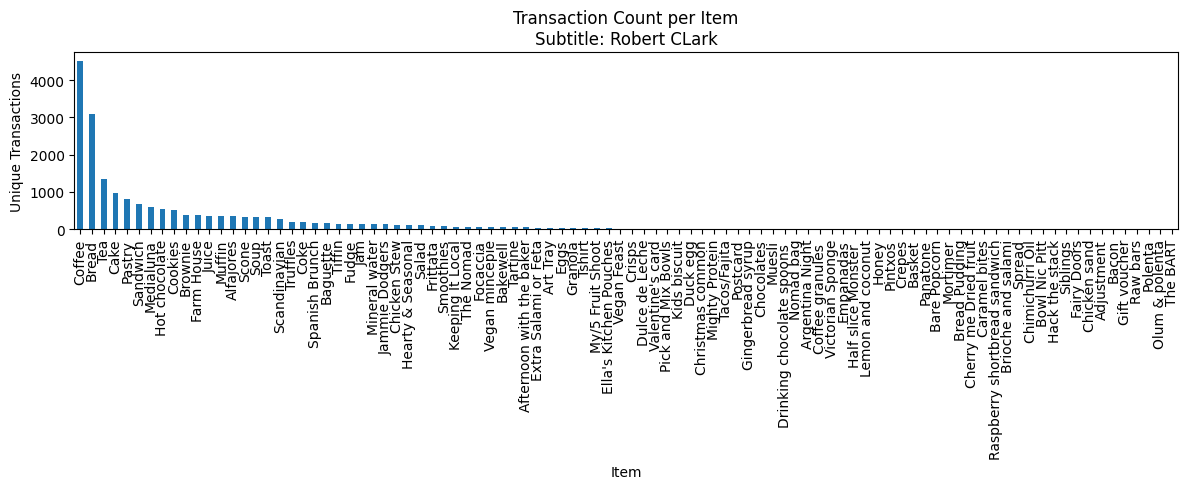

In [35]:
# c) Bar plot of transaction counts per item
subtitle = "Robert CLark"  # <-- EDIT THIS
item_counts = (bread.groupby("item")["transaction"].nunique()  # <-- EDIT THIS
                .sort_values(ascending=False)) #"""<<<---I would like to say this single last parenthesis kept messing me up because i would wrap the statement on the line above"""

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [43]:
# write your answer here
items = ["Alfajores", "Coffee", "Tea", "Juice", "Chicken Stew"]
display(item_counts.loc[items])

,transaction
item,
Alfajores,344
Coffee,4528
Tea,1350
Juice,365
Chicken Stew,123


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [45]:
# write your answer here
freq_item = fpgrowth(oht_b, min_support=0.2, use_colnames=True) #from the hands on activity i just added the minimum into the line.
display(freq_item.sort_values(by="support", ascending=False))

,support,itemsets
1,0.478394,(Coffee)
0,0.327205,(Bread)


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [50]:
# write your answer here
freq_b = fpgrowth(oht_b, min_support=0.02, use_colnames=True)
rules_b = association_rules(freq_b, metric='confidence', min_threshold=0.5)
rules_b[['antecedents','consequents','support','confidence','lift']].sort_values(['lift','confidence'], ascending=False).head(20)

#mostly got these from the hands on activity, but i think my confidence and support threshholds are good because it filters out all but the MOST common and predictable pairs.


,antecedents,consequents,support,confidence,lift
7,(Toast),(Coffee),0.023666,0.704403,1.472431
3,(Medialuna),(Coffee),0.035182,0.569231,1.189878
2,(Pastry),(Coffee),0.047544,0.552147,1.154168
4,(Juice),(Coffee),0.020602,0.534247,1.116750
6,(Sandwich),(Coffee),0.038246,0.532353,1.112792
5,(Cake),(Coffee),0.054728,0.526958,1.101515
1,(Cookies),(Coffee),0.028209,0.518447,1.083723
0,(Hot chocolate),(Coffee),0.029583,0.507246,1.060311


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* (write your answer here)

The rule {Coffee, Cake} -> {Bread} means that the people who buy both Cake and Coffee are also likely to buy Bread with them.


*   Support: if the fraction of times all 3 items were bought is high enough we can predict that when people buy Coffee and Cake they will also buy Bread.

*   Confidence: I see it as how often you can trust that whoever is buying Coffee and Cake is also buying bread. If most cases of Coffee and Cake being bought together also includes Bread then the confidence is going to be really high.

*   Lift > 1: From our slides a lift > 1 is considered a positive association. Basically it is showing is that Coffee and Cake make it much more likely that Bread will be bough. I think this also allows us to make assumptions about the shopper. For example I would put the bread just one aisle over from the Coffee and Cake and then put a lot of really desirable items on the racks leading to the bread. We can't expect the customer to buy the extra things on the shelves, but we can predict they will walk to the bread aisle which gives us the chance to market other items to them along the way.

